<a href="https://colab.research.google.com/github/johnlwilson223-web/Python-projects/blob/main/hamlet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [2]:
!pip install requests

import requests

target_url = 'https://www.gutenberg.org/files/2265/2265-0.txt'

response = requests.get(target_url)

data = response.text

In [3]:
from textblob import TextBlob

blob = TextBlob(data)

In [4]:
print(blob[:500])

*** START OF THE PROJECT GUTENBERG EBOOK 2265 ***


Executive Director's Notes:

In addition to the notes below, and so you will *NOT* think all
the spelling errors introduced by the printers of the time have
been corrected, here are the first few lines of Hamlet, as they
are presented herein:

  Barnardo. Who's there?
  Fran. Nay answer me: Stand & vnfold
your selfe

   Bar. Long liue the King

       *       *       *       *       *

As I understand it, the printers often ra


In [8]:
from nltk.corpus import stopwords

stop_words = stopwords.words('english')

items = blob.word_counts.items()

items = [item for item in items if item[0] not in stop_words]

from operator import itemgetter

sorted_items = sorted(items, key=itemgetter(1), reverse=True)

top20 = sorted_items[:20]

top20

[('ham', 337),
 ('lord', 211),
 ('haue', 175),
 ('king', 173),
 ('shall', 107),
 ('come', 106),
 ('thou', 105),
 ('let', 104),
 ('hamlet', 100),
 ('good', 98),
 ('hor', 95),
 ('thy', 90),
 ('enter', 85),
 ('oh', 81),
 ('like', 78),
 ('well', 70),
 ('may', 69),
 ('know', 69),
 ('selfe', 68),
 ('would', 68)]

In [7]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Text(0, 0.5, 'Frequency')

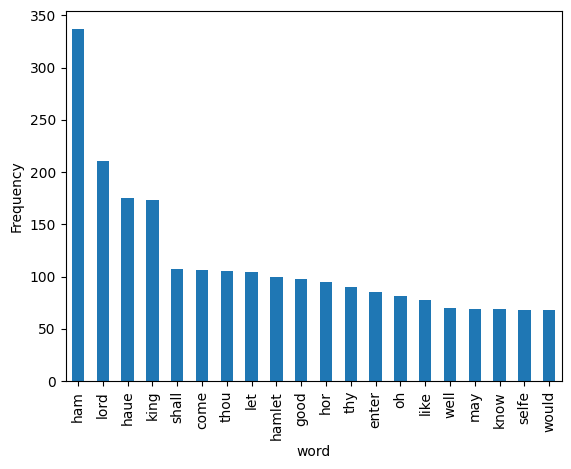

In [9]:
import pandas as pd

df = pd.DataFrame(top20, columns=['word', 'count'])

axes = df.plot.bar(x='word', y='count', legend=False)

axes.set_ylabel('Frequency')

In [10]:
import imageio

image_file = "https://media.cheggcdn.com/media/216/21621ee5-e80f-47f3-9145-513f2229b390/phploeBuh.png"

mask_image = imageio.v3.imread(image_file)

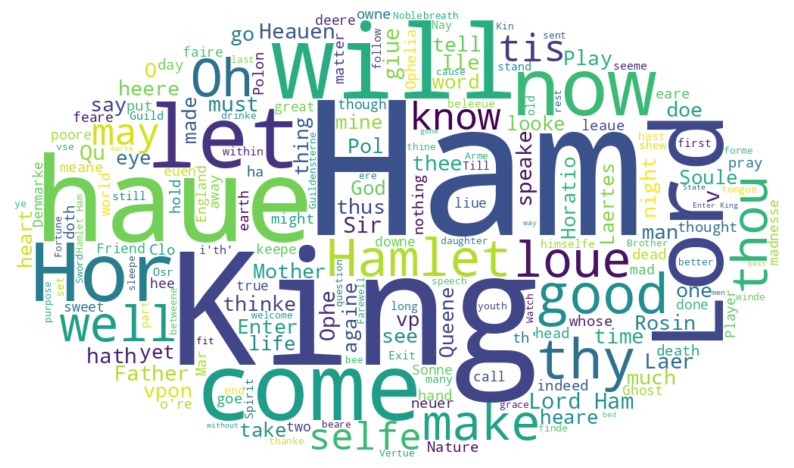

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=1000,
    height=1000,
    mask=mask_image,
    background_color='white'
)

wordcloud = wordcloud.generate(data)

plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()